In [1]:
import librosa
import matplotlib.pyplot as plt
import numpy as np


c:\Users\justi\dev\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Example shape  (1321967,) Sample rate  44100 Data type <class 'numpy.ndarray'>


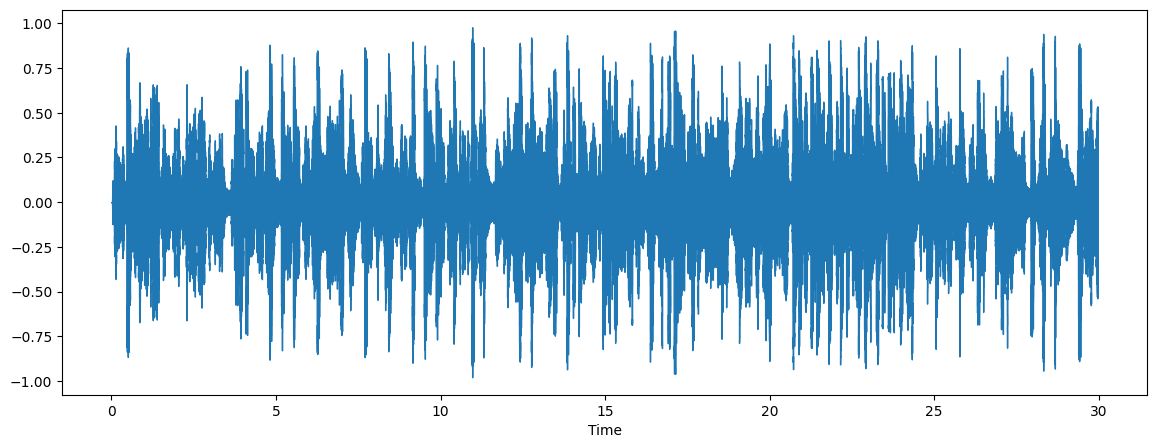

In [2]:
# Load the audio file
AUDIO_FILE = './data/0-of-15/waveforms/0_Food_AWOL.wav'
samples, sample_rate = librosa.load(AUDIO_FILE, sr=None)


# x-axis has been converted to time using our sample rate. 
# matplotlib plt.plot(y), would output the same figure, but with sample 
# number on the x-axis instead of seconds
plt.figure(figsize=(14, 5))
librosa.display.waveshow(samples, sr=sample_rate)
print ('Example shape ', samples.shape, 'Sample rate ', sample_rate, 'Data type', type(samples))



In [8]:
from IPython.display import Audio
Audio(AUDIO_FILE)

C:\Users\justi\AppData\Local\Temp\ipykernel_20724\2680270098.py:2: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  librosa.display.specshow(sgram)


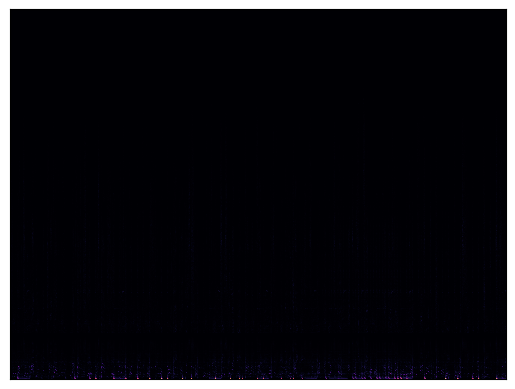

In [3]:
sgram = librosa.stft(samples)
librosa.display.specshow(sgram)
# use the mel-scale instead of raw frequency
sgram_mag, _ = librosa.magphase(sgram)
mel_scale_sgram = librosa.feature.melspectrogram(S=sgram_mag, sr=sample_rate)
librosa.display.specshow(mel_scale_sgram)

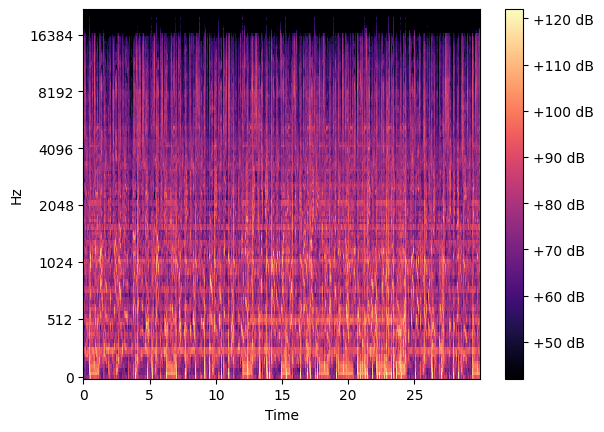

In [4]:

# use the decibel scale to get the final Mel Spectrogram
mel_sgram = librosa.amplitude_to_db(mel_scale_sgram, ref=np.min)
librosa.display.specshow(mel_sgram, sr=sample_rate, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')

In [7]:
print(type(mel_sgram))
print(mel_sgram)
print(mel_sgram.shape)


<class 'numpy.ndarray'>
[[ 42.00863   42.00863   65.27037  ...  92.85984   92.61162   97.45567 ]
 [ 42.00863   46.698868  63.294273 ... 104.19295  102.84597  100.15493 ]
 [ 42.00863   57.421654  67.40615  ...  98.52238   99.595856  98.19293 ]
 ...
 [ 42.00863   42.00863   42.00863  ...  42.00863   42.00863   42.00863 ]
 [ 42.00863   42.00863   42.00863  ...  42.00863   42.00863   42.00863 ]
 [ 42.00863   42.00863   42.00863  ...  42.00863   42.00863   42.00863 ]]
(128, 2582)


In [ ]:
import torch
import numpy

mel = np.load("data/mels/0-of-15/0_Food_AWOL.npy")
mel = torch.from_numpy(mel)
print(type(mel))
print(mel.shape)
print(mel)



<class 'torch.Tensor'>
torch.Size([128, 1291])
tensor([[-67.4136, -51.2373, -47.8371,  ..., -41.8144, -37.4783, -29.4915],
        [-68.7390, -54.8450, -52.8367,  ..., -16.3929, -16.7171, -17.7015],
        [-71.2410, -62.0938, -56.7534,  ..., -16.1513, -15.8932, -18.7337],
        ...,
        [-80.0000, -71.1390, -58.5513,  ..., -41.3766, -44.3872, -50.0145],
        [-80.0000, -76.4677, -60.6038,  ..., -43.8166, -46.8066, -54.8886],
        [-80.0000, -80.0000, -71.1083,  ..., -53.6248, -55.5160, -64.3792]])
